In [1]:
import json

# Load configuration and define a global variable
def load_config():
    global config
    with open('config_Distributions.json') as config_file:
        config = json.load(config_file)

# Call the function to load the configuration
load_config()

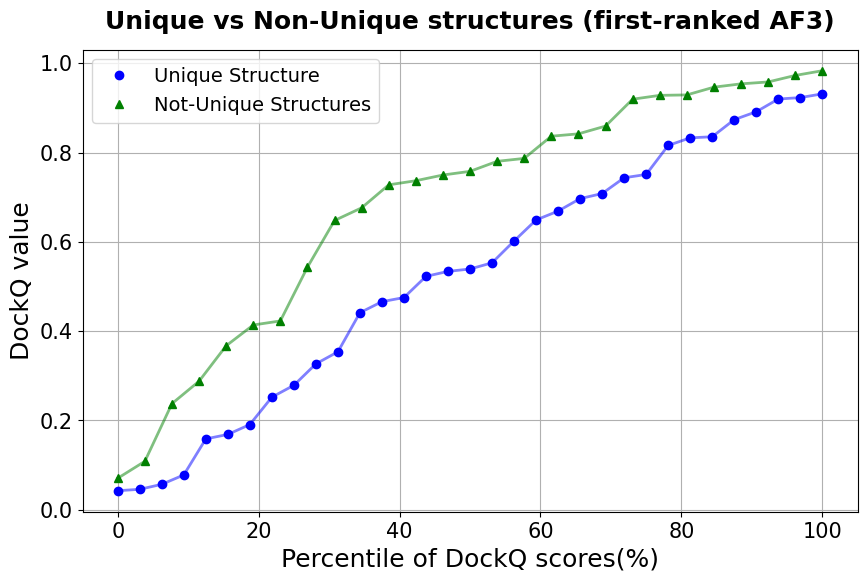

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import json

def get_dockq_value(file_path):
    """
    Reads an Excel file and returns the DockQ value.
    This function assumes the Excel file has either:
      - A column named 'DockQ' (and we use its first value), or
      - No header, so we take the first cell.
    Modify this function if your files have a different structure.
    """
    try:
        df = pd.read_excel(file_path)
        if 'DockQ' in df.columns:
            return df['DockQ'].iloc[0]
        else:
            # If there's no header, assume the value is in the first cell.
            return df.iloc[0, 0]
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

def load_dockq_values(folder_path):
    """
    Reads all Excel files in the specified folder and returns a DataFrame 
    with filenames and corresponding DockQ values.
    """
    file_paths = glob.glob(os.path.join(folder_path, "*.xlsx"))
    data = []
    for file_path in file_paths:
        value = get_dockq_value(file_path)
        if value is not None:
            data.append({'File': os.path.basename(file_path), 'DockQ': value})
    return pd.DataFrame(data)

# Load configuration and define a global variable
def load_config():
    global config
    with open('config_Distributions.json') as config_file:
        config = json.load(config_file)

# Call the function to load the configuration
load_config()


unique_folder = 'path to /PpEv/Analysis/Supplemenrary/Data/unique_first'
not_unique_folder = 'path to /PpEv/Analysis/Supplemenrary/Data/n_unique_all_first'

# Load data for both groups
unique_df = load_dockq_values(unique_folder)
not_unique_df = load_dockq_values(not_unique_folder)

# Sort each DataFrame by the DockQ value (ascending)
unique_df_sorted = unique_df.sort_values(by="DockQ").reset_index(drop=True)
not_unique_df_sorted = not_unique_df.sort_values(by="DockQ").reset_index(drop=True)

# Calculate the percentile for each sample.
unique_df_sorted['Percentile'] = unique_df_sorted.index / (len(unique_df_sorted) - 1) * 100
not_unique_df_sorted['Percentile'] = not_unique_df_sorted.index / (len(not_unique_df_sorted) - 1) * 100

plt.figure(figsize=(10, 6))

# Plot the connecting lines with lighter opacity
plt.plot(unique_df_sorted['Percentile'], unique_df_sorted['DockQ'],
         linestyle='-', color='blue', linewidth=2, alpha=0.5)
plt.plot(not_unique_df_sorted['Percentile'], not_unique_df_sorted['DockQ'],
         linestyle='-', color='green', linewidth=2, alpha=0.5)

# Plot the markers on top with full opacity
plt.plot(unique_df_sorted['Percentile'], unique_df_sorted['DockQ'],
         marker='o', linestyle='None', color='blue', markersize=6, label='Unique Structure')
plt.plot(not_unique_df_sorted['Percentile'], not_unique_df_sorted['DockQ'],
         marker='^', linestyle='None', color='green', markersize=6, label='Not-Unique Structures')

# Set font sizes for labels, title, ticks, and legend
plt.xlabel('Percentile of DockQ scores(%)', fontsize=18)
plt.ylabel('DockQ value', fontsize=18)
plt.title('Unique vs Non-Unique structures (first-ranked AF3)', fontsize=18, fontweight='bold', pad=15)
plt.legend(fontsize=14)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True)

# Save the figure as a high-quality PNG (1000 dpi) to the directory specified in the config file
output_directory = config["Supp_Figures_directory"]
os.makedirs(output_directory, exist_ok=True)
output_file = os.path.join(output_directory, "Figure_S17_a.jpeg")
plt.savefig(output_file, dpi=1000, bbox_inches='tight')

plt.show()


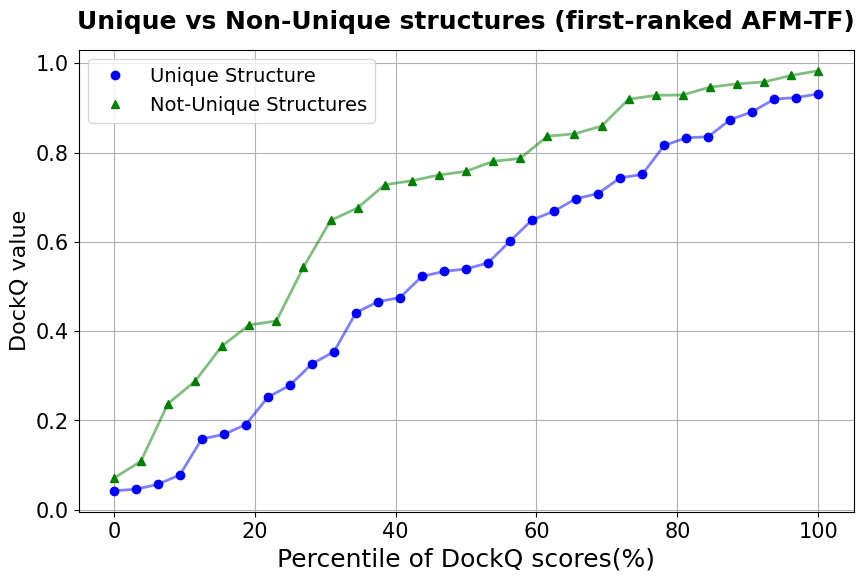

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import json

# Load configuration and define a global variable
def load_config():
    global config
    with open('config_Distributions.json') as config_file:
        config = json.load(config_file)

# Call the function to load the configuration
load_config()

def get_dockq_value(file_path):
    """
    Reads an Excel file and returns the DockQ value.
    This function assumes the Excel file has either:
      - A column named 'DockQ' (and we use its first value), or
      - No header, so we take the first cell.
    Modify this function if your files have a different structure.
    """
    try:
        df = pd.read_excel(file_path)
        if 'DockQ' in df.columns:
            return df['DockQ'].iloc[0]
        else:
            # If there's no header, assume the value is in the first cell.
            return df.iloc[0, 0]
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

def load_dockq_values(folder_path):
    """
    Reads all Excel files in the specified folder and returns a DataFrame 
    with filenames and corresponding DockQ values.
    """
    file_paths = glob.glob(os.path.join(folder_path, "*.xlsx"))
    data = []
    for file_path in file_paths:
        value = get_dockq_value(file_path)
        if value is not None:
            data.append({'File': os.path.basename(file_path), 'DockQ': value})
    return pd.DataFrame(data)

unique_folder = 'path to /PpEv/Analysis/Supplemenrary/Data/unique_first'
not_unique_folder = 'path to /PpEv/Analysis/Supplemenrary/Data/n_unique_all_first'

# Load data for both groups
unique_df = load_dockq_values(unique_folder)
not_unique_df = load_dockq_values(not_unique_folder)

# Sort each DataFrame by the DockQ value (ascending)
unique_df_sorted = unique_df.sort_values(by="DockQ").reset_index(drop=True)
not_unique_df_sorted = not_unique_df.sort_values(by="DockQ").reset_index(drop=True)

# Calculate the percentile for each sample.
# Formula: (index / (total_samples - 1)) * 100 gives percentiles from 0 to 100.
unique_df_sorted['Percentile'] = unique_df_sorted.index / (len(unique_df_sorted) - 1) * 100
not_unique_df_sorted['Percentile'] = not_unique_df_sorted.index / (len(not_unique_df_sorted) - 1) * 100

plt.figure(figsize=(10, 6))

# Plot the connecting lines with lighter opacity (alpha=0.5)
plt.plot(unique_df_sorted['Percentile'], unique_df_sorted['DockQ'],
         linestyle='-', color='blue', linewidth=2, alpha=0.5)
plt.plot(not_unique_df_sorted['Percentile'], not_unique_df_sorted['DockQ'],
         linestyle='-', color='green', linewidth=2, alpha=0.5)

# Plot the markers on top with full opacity to stand out
plt.plot(unique_df_sorted['Percentile'], unique_df_sorted['DockQ'],
         marker='o', linestyle='None', color='blue', markersize=6, label='Unique Structure')
plt.plot(not_unique_df_sorted['Percentile'], not_unique_df_sorted['DockQ'],
         marker='^', linestyle='None', color='green', markersize=6, label='Not-Unique Structures')

# Set font sizes for labels, title, ticks, and legend
plt.xlabel('Percentile of DockQ scores(%)', fontsize=18)
plt.ylabel('DockQ value', fontsize=16)
plt.title('Unique vs Non-Unique structures (first-ranked AFM-TF)', fontsize=18, fontweight='bold', pad=15)
plt.legend(fontsize=14)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True)

# Save the figure as a high-quality PNG (1000 dpi) to the directory specified in the config file
output_directory = config["Supp_Figures_directory"]
os.makedirs(output_directory, exist_ok=True)
output_file = os.path.join(output_directory, "Figure_S17_b.jpeg")
plt.savefig(output_file, dpi=1000, bbox_inches='tight')

plt.show()


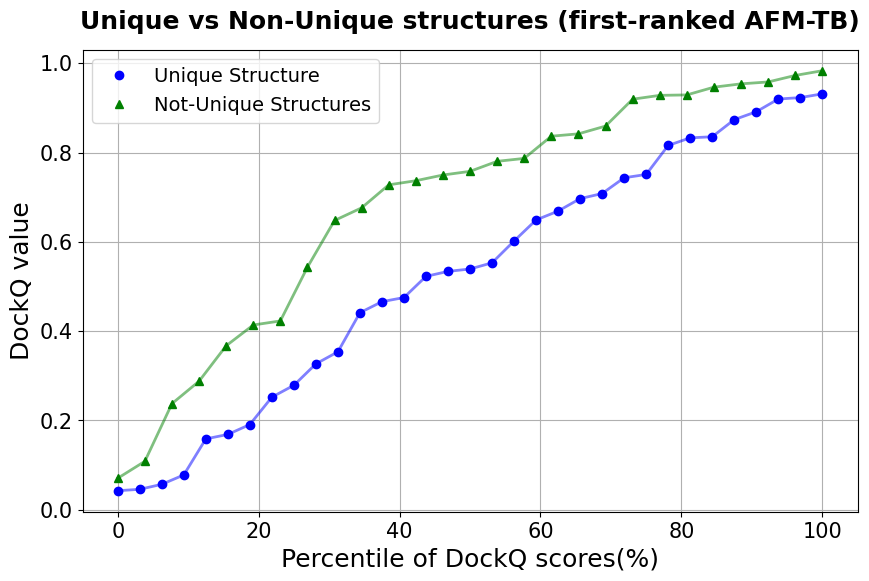

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import json

# Load configuration and define a global variable
def load_config():
    global config
    with open('config_Distributions.json') as config_file:
        config = json.load(config_file)

# Call the function to load the configuration
load_config()

def get_dockq_value(file_path):
    """
    Reads an Excel file and returns the DockQ value.
    This function assumes the Excel file has either:
      - A column named 'DockQ' (and we use its first value), or
      - No header, so we take the first cell.
    Modify this function if your files have a different structure.
    """
    try:
        df = pd.read_excel(file_path)
        if 'DockQ' in df.columns:
            return df['DockQ'].iloc[0]
        else:
            # If there's no header, assume the value is in the first cell.
            return df.iloc[0, 0]
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

def load_dockq_values(folder_path):
    """
    Reads all Excel files in the specified folder and returns a DataFrame 
    with filenames and corresponding DockQ values.
    """
    file_paths = glob.glob(os.path.join(folder_path, "*.xlsx"))
    data = []
    for file_path in file_paths:
        value = get_dockq_value(file_path)
        if value is not None:
            data.append({'File': os.path.basename(file_path), 'DockQ': value})
    return pd.DataFrame(data)


unique_folder = 'path to /PpEv/Analysis/Supplemenrary/Data/unique_first'
not_unique_folder = 'path to /PpEv/Analysis/Supplemenrary/Data/n_unique_all_first'

# Load data for both groups
unique_df = load_dockq_values(unique_folder)
not_unique_df = load_dockq_values(not_unique_folder)

# Sort each DataFrame by the DockQ value (ascending)
unique_df_sorted = unique_df.sort_values(by="DockQ").reset_index(drop=True)
not_unique_df_sorted = not_unique_df.sort_values(by="DockQ").reset_index(drop=True)

# Calculate the percentile for each sample.
unique_df_sorted['Percentile'] = unique_df_sorted.index / (len(unique_df_sorted) - 1) * 100
not_unique_df_sorted['Percentile'] = not_unique_df_sorted.index / (len(not_unique_df_sorted) - 1) * 100

plt.figure(figsize=(10, 6))

# Plot the connecting lines with lighter opacity (alpha=0.5)
plt.plot(unique_df_sorted['Percentile'], unique_df_sorted['DockQ'],
         linestyle='-', color='blue', linewidth=2, alpha=0.5)
plt.plot(not_unique_df_sorted['Percentile'], not_unique_df_sorted['DockQ'],
         linestyle='-', color='green', linewidth=2, alpha=0.5)

# Plot the markers on top with full opacity to stand out
plt.plot(unique_df_sorted['Percentile'], unique_df_sorted['DockQ'],
         marker='o', linestyle='None', color='blue', markersize=6, label='Unique Structure')
plt.plot(not_unique_df_sorted['Percentile'], not_unique_df_sorted['DockQ'],
         marker='^', linestyle='None', color='green', markersize=6, label='Not-Unique Structures')

# Set font sizes for labels, title, ticks, and legend
plt.xlabel('Percentile of DockQ scores(%)', fontsize=18)
plt.ylabel('DockQ value', fontsize=18)
plt.title('Unique vs Non-Unique structures (first-ranked AFM-TB)', fontsize=18, fontweight='bold', pad=15)
plt.legend(fontsize=14)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True)

# Save the figure as a high quality PNG (1000 dpi) in the directory specified in the config file
output_directory = config["Supp_Figures_directory"]
os.makedirs(output_directory, exist_ok=True)
output_file = os.path.join(output_directory, "Figure_S17_c.jpeg")
plt.savefig(output_file, dpi=1000, bbox_inches='tight')

plt.show()
